In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
df =  pd.read_parquet("all_teams_last10seasons_with_opponent_rolls.parquet")

In [2]:
target = 'TARGET_WL'
exclude_cols = [
    'Team_ID',      
    'Team_ID_opp',  
    'Game_ID',     
    target
]

features = [col for col in df.columns if col not in exclude_cols]

In [3]:
df_model = df.dropna(subset=features + [target])

# Split chronologically (e.g., 80% train, 20% test)
split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [4]:
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)

/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_23139/2585570748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[bool_cols] = X_train[bool_cols].astype(int)
/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_23139/2585570748.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[bool_cols] = X_test[bool_cols].astype(int)


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Standardize Data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2️⃣ Fit Full PCA and Inspect Variance ---
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"\n Current Feature Count: {X_train.shape[1]}")


print(f"\n Variance Explained by Components:")
print(f"  First 5 components: {cumulative_variance[4]:.1%}")
print(f"  First 10 components: {cumulative_variance[9]:.1%}")
print(f"  First 15 components: {cumulative_variance[14]:.1%}")
print(f"  First 20 components: {cumulative_variance[19]:.1%}")

n_components_50 = np.argmax(cumulative_variance >= 0.50) + 1
n_components_65 = np.argmax(cumulative_variance >= 0.65) + 1
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.85) + 1
print(f"  Number of PCs for 65% variance: {n_components_65}")
print(f"  Number of PCs for 80% variance: {n_components_80}")
print(f"  Number of PCs for 90% variance: {n_components_90}")

# --- Fit Optimal PCA and Inspect Top Features ---

# Choice of n_components can be adjusted based on analysis above
n_components_optimal = n_components_50
pca_optimal = PCA(n_components=n_components_optimal)
pca_optimal.fit(X_train_scaled)


 Current Feature Count: 53

 Variance Explained by Components:
  First 5 components: 35.4%
  First 10 components: 52.7%
  First 15 components: 64.4%
  First 20 components: 74.1%
  Number of PCs for 65% variance: 16
  Number of PCs for 80% variance: 24
  Number of PCs for 90% variance: 27


,n_components,np.int64(24)
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Transform Data into Principal Components ---
X_train = pca_optimal.transform(X_train_scaled)
X_test = pca_optimal.transform(X_test_scaled)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import statsmodels.api as sm

# --- 1. Final tuned Logistic Regression pipeline ---
final_log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000,
        penalty='l1',       # tuned best param
        C=0.01,             # tuned best param
        solver='saga',      # tuned best param
        l1_ratio=0          # tuned best param (only for elasticnet, saga allows l1)
    ))
])

# Fit on training data
final_log_model.fit(X_train, y_train)

# Predict on test data
y_pred_log = final_log_model.predict(X_test)

# --- 2. Print standard metrics ---
print("\n=== Logistic Regression (tuned) Metrics ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print("Precision (macro):", round(precision_score(y_test, y_pred_log, average='macro'), 3))
print("Recall (macro):", round(recall_score(y_test, y_pred_log, average='macro'), 3))
print("F1-score (macro):", round(f1_score(y_test, y_pred_log, average='macro'), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# --- 3. Optional: statsmodels Logit for AIC/BIC and coefficients ---
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

sm_model = sm.Logit(y_train, X_train_sm).fit()

y_proba_sm = sm_model.predict(X_test_sm)
y_pred_sm = (y_proba_sm >= 0.5).astype(int)

print("\nAIC:", sm_model.aic.round(2))
print("BIC:", sm_model.bic.round(2))


=== Logistic Regression (tuned) Metrics ===
Accuracy: 0.624
Precision (macro): 0.608
Recall (macro): 0.609
F1-score (macro): 0.608

Confusion Matrix:
 [[821 385]
 [360 417]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.68      0.69      1206
           1       0.52      0.54      0.53       777

    accuracy                           0.62      1983
   macro avg       0.61      0.61      0.61      1983
weighted avg       0.63      0.62      0.63      1983

Optimization terminated successfully.
         Current function value: 0.652465
         Iterations 5

AIC: 10399.4
BIC: 10573.86


/Users/joshuademontigny/Downloads/ML_NBA_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# --- SVM (tuned) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    C=1,
    gamma=0.001,
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\n=== SVM (tuned) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm), 3))
print("Precision (macro):", round(precision_score(y_test, y_pred_svm, average='macro'), 3))
print("Recall (macro):", round(recall_score(y_test, y_pred_svm, average='macro'), 3))
print("F1-score (macro):", round(f1_score(y_test, y_pred_svm, average='macro'), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


=== SVM (tuned) ===
Accuracy: 0.645
Precision (macro): 0.632
Recall (macro): 0.636
F1-score (macro): 0.633

Confusion Matrix:
 [[818 388]
 [316 461]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.68      0.70      1206
           1       0.54      0.59      0.57       777

    accuracy                           0.64      1983
   macro avg       0.63      0.64      0.63      1983
weighted avg       0.65      0.64      0.65      1983



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# --- Random Forest (tuned) ---
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest (tuned) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision (macro):", round(precision_score(y_test, y_pred_rf, average='macro'), 3))
print("Recall (macro):", round(recall_score(y_test, y_pred_rf, average='macro'), 3))
print("F1-score (macro):", round(f1_score(y_test, y_pred_rf, average='macro'), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


=== Random Forest (tuned) ===
Accuracy: 0.623
Precision (macro): 0.615
Recall (macro): 0.62
F1-score (macro): 0.614

Confusion Matrix:
 [[763 443]
 [305 472]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.63      0.67      1206
           1       0.52      0.61      0.56       777

    accuracy                           0.62      1983
   macro avg       0.62      0.62      0.61      1983
weighted avg       0.64      0.62      0.63      1983



In [13]:
from xgboost import XGBClassifier
import pandas as pd

from xgboost import XGBClassifier

# --- 1️⃣ Train XGBoost using tuned hyperparameters ---
xgb_model = XGBClassifier(
    objective="binary:logistic",  # binary classification
    eval_metric="logloss",
    tree_method="hist",           # fast on Apple Silicon
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

# --- 2️⃣ Predict ---
y_pred_xgb = xgb_model.predict(X_test)        # predicted class labels
y_proba_xgb = xgb_model.predict_proba(X_test) # predicted probabilities for soft voting

In [16]:
import os
output_folder = "tables"
os.makedirs(output_folder, exist_ok=True)

results = []

# Logistic Regression
results.append({
    "model": "Logistic Regression (tuned)",
    "accuracy": round(accuracy_score(y_test, y_pred_log), 2),
    "precision": round(precision_score(y_test, y_pred_log, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_log, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_log, average='macro'), 2)
})

# SVM
results.append({
    "model": "SVM (tuned)",
    "accuracy": round(accuracy_score(y_test, y_pred_svm), 2),
    "precision": round(precision_score(y_test, y_pred_svm, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_svm, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_svm, average='macro'), 2)
})

# Random Forest
results.append({
    "model": "Random Forest (tuned)",
    "accuracy": round(accuracy_score(y_test, y_pred_rf), 2),
    "precision": round(precision_score(y_test, y_pred_rf, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_rf, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_rf, average='macro'), 2)
})

# XGBoost
results.append({
    "model": "XGBoost (tuned)",
    "accuracy": round(accuracy_score(y_test, y_pred_xgb), 2),
    "precision": round(precision_score(y_test, y_pred_xgb, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_xgb, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_xgb, average='macro'), 2)
})

# --- 4️⃣ Save results ---
comparison_table = pd.DataFrame(results)
comparison_table.to_csv(os.path.join(output_folder, "model_comparison.csv"), index=False)

print("Model comparison table saved to tables/model_comparison.csv")
print(comparison_table)

✅ Model comparison table saved to tables/model_comparison.csv
                         model  accuracy  precision  recall  f1_score
0  Logistic Regression (tuned)      0.62       0.61    0.61      0.61
1                  SVM (tuned)      0.64       0.63    0.64      0.63
2        Random Forest (tuned)      0.62       0.62    0.62      0.61
3              XGBoost (tuned)      0.62       0.60    0.60      0.60


In [18]:
loadings = pd.DataFrame(
    pca_optimal.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)],
    index=features
)

print(f"\n Top Features for First 10 PCs:")
print("="*60)
for i in range(min(10, n_components_optimal)):
    pc_name = f'PC{i+1}'
    print(f"\n{pc_name} (explains {pca_optimal.explained_variance_ratio_[i]:.1%} of variance):")
    top_loadings = loadings[pc_name].abs().sort_values(ascending=False).head(3)
    for feature in top_loadings.index:
        print(f"  {feature:40s}: {loadings.loc[feature, pc_name]:>7.3f}")


 Top Features for First 10 PCs:

PC1 (explains 8.4% of variance):
  FG_PCT_DIFF                             :   0.401
  WIN_PCT_DIFF                            :   0.352
  EFG_PCT_rolling5                        :   0.302

PC2 (explains 8.1% of variance):
  GAMES_IN_LAST_14                        :   0.361
  GAMES_IN_LAST_14_opp                    :   0.359
  PACE_MATCHUP                            :  -0.310

PC3 (explains 6.8% of variance):
  EFG_PCT_rolling5_opp                    :   0.347
  PTS_rolling5                            :   0.333
  EFG_PCT_rolling5                        :   0.332

PC4 (explains 6.3% of variance):
  PACE_MATCHUP                            :   0.374
  PACE_rolling5_opp                       :   0.332
  FGA_rolling5_opp                        :   0.322

PC5 (explains 5.9% of variance):
  REB_MARGIN                              :   0.449
  FGA_rolling5                            :   0.403
  PACE_rolling5                           :   0.368

PC6 (explains 4.

In [15]:
# --- SOFT VOTING ENSEMBLE ---
y_proba_log = final_log_model.predict_proba(X_test)
y_proba_svm = svm_model.predict_proba(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)

# ---- Simple average (soft voting with XGB) ----
avg_proba = (y_proba_log + y_proba_svm + y_proba_rf + y_proba_xgb) / 4
y_pred_ensemble_soft = np.argmax(avg_proba, axis=1)


# Compute metrics
soft_result = {
    "model": "Ensemble Soft Voting",
    "accuracy": round(accuracy_score(y_test, y_pred_ensemble_soft), 2),
    "precision": round(precision_score(y_test, y_pred_ensemble_soft, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_ensemble_soft, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_ensemble_soft, average='macro'), 2)
}

# ---- 2️⃣ Weighted soft voting ----
weights = [0.4, 0.15, 0.15, 0.3]
weighted_avg_proba = (
    weights[0]*y_proba_log +
    weights[1]*y_proba_svm +
    weights[2]*y_proba_rf +
    weights[3]*y_proba_xgb
) / sum(weights)
y_pred_ensemble_weighted = np.argmax(weighted_avg_proba, axis=1)


weighted_result = {
    "model": "Ensemble Weighted Soft Voting",
    "accuracy": round(accuracy_score(y_test, y_pred_ensemble_weighted), 2),
    "precision": round(precision_score(y_test, y_pred_ensemble_weighted, average='macro'), 2),
    "recall": round(recall_score(y_test, y_pred_ensemble_weighted, average='macro'), 2),
    "f1_score": round(f1_score(y_test, y_pred_ensemble_weighted, average='macro'), 2)
}

# --- Remove any previous ensemble entries if rerunning ---
results = [r for r in results if "Ensemble" not in r["model"]]

# --- Append new ensemble results ---
results.extend([soft_result, weighted_result])

# --- Convert to DataFrame and save ---
comparison_table = pd.DataFrame(results)
comparison_table.to_csv(os.path.join(output_folder, "model_comparison.csv"), index=False)

print("✅ Updated model comparison table saved to tables/model_comparison.csv")
print(comparison_table)

✅ Updated model comparison table saved to tables/model_comparison.csv
                           model  accuracy  precision  recall  f1_score
0    Logistic Regression (tuned)      0.62       0.61    0.61      0.61
1                    SVM (tuned)      0.64       0.63    0.64      0.63
2          Random Forest (tuned)      0.62       0.62    0.62      0.61
3                XGBoost (tuned)      0.62       0.60    0.60      0.60
4           Ensemble Soft Voting      0.63       0.62    0.62      0.62
5  Ensemble Weighted Soft Voting      0.63       0.61    0.62      0.61


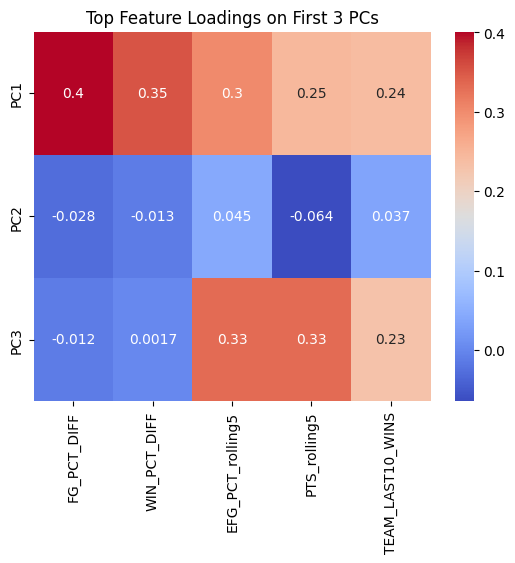

In [20]:
import seaborn as sns

top_features = ['FG_PCT_DIFF','WIN_PCT_DIFF','EFG_PCT_rolling5','PTS_rolling5','TEAM_LAST10_WINS']
pc_loadings = pca_optimal.components_[:3, [features.index(f) for f in top_features]]  # adjust to match your pca object
sns.heatmap(pc_loadings, annot=True, cmap='coolwarm', yticklabels=['PC1','PC2','PC3'], xticklabels=top_features)
plt.title("Top Feature Loadings on First 3 PCs")
plt.show()